In [ ]:
from google.colab import files
uploaded = files.upload()


Saving data.csv to data.csv


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving weatherdata.csv to weatherdata.csv


In [ ]:
import pandas as pd

df = pd.read_csv("data.csv")
df.head()


,Unnamed: 0,T,TM,Tm,SLP,H,VV,V,VM,PM 2.5
0,0,7.4,9.8,4.8,1017.6,93.0,0.5,4.3,9.4,219.720833
1,1,7.8,12.7,4.4,1018.5,87.0,0.6,4.4,11.1,182.187500
2,2,6.7,13.4,2.4,1019.4,82.0,0.6,4.8,11.1,154.037500
3,3,8.6,15.5,3.3,1018.7,72.0,0.8,8.1,20.6,223.208333
4,4,12.4,20.9,4.4,1017.3,61.0,1.3,8.7,22.2,200.645833


In [ ]:
import pandas as pd

df = pd.read_csv("weatherdata.csv")
df.head()

,Date,Year,Month,Max Temperature,Avg Temperature,Min Temperature,Max Dew Point,Avg Dew Point,Min Dew Point,Max Humidity,Avg Humidity,Min Humidity,Max Wind Speed,Avg Wind Speed,Min Wind Speed,Max Pressure,Avg Pressure,Min Pressure,Total Precipitation
0,1,2010,1,70.0,55.7,45.0,52.0,47.5,41.0,100.0,77.5,43.0,8.0,4.9,0.0,29.2,29.2,29.1,0.0
1,2,2010,1,59.0,50.6,46.0,54.0,49.6,46.0,100.0,96.7,77.0,8.0,4.8,3.0,29.3,29.3,29.2,0.0
2,3,2010,1,57.0,52.8,48.0,57.0,52.1,48.0,100.0,97.3,82.0,12.0,7.4,3.0,29.3,29.2,29.2,0.0
3,4,2010,1,55.0,51.0,48.0,50.0,48.4,48.0,100.0,91.9,77.0,15.0,11.0,7.0,29.3,29.2,29.1,0.0
4,5,2010,1,63.0,53.1,46.0,52.0,47.9,46.0,100.0,85.1,55.0,14.0,5.7,0.0,29.2,29.1,29.1,0.0


In [ ]:
import pandas as pd

# Load the CSV that you uploaded
df = pd.read_csv("data.csv")

# Remove the wrong column (unnamed index column)
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# Rename last column properly if needed
df.rename(columns={"PM 2.5": "PM25", "PM 2.5 ": "PM25"}, inplace=True)

# Convert all columns to numeric (very important!)
df = df.apply(pd.to_numeric, errors='coerce')

# Show cleaned dataset
df.head()


,T,TM,Tm,SLP,H,VV,V,VM,PM25
0,7.4,9.8,4.8,1017.6,93.0,0.5,4.3,9.4,219.720833
1,7.8,12.7,4.4,1018.5,87.0,0.6,4.4,11.1,182.187500
2,6.7,13.4,2.4,1019.4,82.0,0.6,4.8,11.1,154.037500
3,8.6,15.5,3.3,1018.7,72.0,0.8,8.1,20.6,223.208333
4,12.4,20.9,4.4,1017.3,61.0,1.3,8.7,22.2,200.645833


In [ ]:
import pandas as pd

# Load the dataset
df_weather = pd.read_csv("weatherdata.csv")

# ---------------------------
# 1. Clean column names
# ---------------------------
df_weather.columns = (
    df_weather.columns
    .str.strip()                     # remove leading/trailing spaces
    .str.replace(" ", "_")           # replace spaces with underscores
    .str.replace(".", "", regex=False)  # remove dots
)

# ---------------------------
# 2. Convert all numeric columns
# ---------------------------
for col in df_weather.columns:
    if col not in ["Date"]:         # if Date exists, don't convert it
        df_weather[col] = pd.to_numeric(df_weather[col], errors="coerce")

# ---------------------------
# 3. Create a combined datetime column
# ---------------------------

# Some datasets have Year + Month only → create a date as first day of month
df_weather["Date"] = pd.to_datetime(
    df_weather["Year"].astype(str) + "-" + df_weather["Month"].astype(str) + "-01"
)

# ---------------------------
# 4. Handle missing values
# ---------------------------
df_weather = df_weather.dropna()     # simplest method

# ---------------------------
# 5. Drop duplicates
# ---------------------------
df_weather = df_weather.drop_duplicates()

# ---------------------------
# Show cleaned dataset
# ---------------------------
df_weather.head()


,Date,Year,Month,Max_Temperature,Avg_Temperature,Min_Temperature,Max_Dew_Point,Avg_Dew_Point,Min_Dew_Point,Max_Humidity,Avg_Humidity,Min_Humidity,Max_Wind_Speed,Avg_Wind_Speed,Min_Wind_Speed,Max_Pressure,Avg_Pressure,Min_Pressure,Total_Precipitation
0,2010-01-01,2010,1,70.0,55.7,45.0,52.0,47.5,41.0,100.0,77.5,43.0,8.0,4.9,0.0,29.2,29.2,29.1,0.0
1,2010-01-01,2010,1,59.0,50.6,46.0,54.0,49.6,46.0,100.0,96.7,77.0,8.0,4.8,3.0,29.3,29.3,29.2,0.0
2,2010-01-01,2010,1,57.0,52.8,48.0,57.0,52.1,48.0,100.0,97.3,82.0,12.0,7.4,3.0,29.3,29.2,29.2,0.0
3,2010-01-01,2010,1,55.0,51.0,48.0,50.0,48.4,48.0,100.0,91.9,77.0,15.0,11.0,7.0,29.3,29.2,29.1,0.0
4,2010-01-01,2010,1,63.0,53.1,46.0,52.0,47.9,46.0,100.0,85.1,55.0,14.0,5.7,0.0,29.2,29.1,29.1,0.0


In [ ]:
import pandas as pd

aqi = pd.read_csv("data.csv")
weather = pd.read_csv("weatherdata.csv")

# Drop useless index column from AQI
aqi = aqi.drop(columns=["Unnamed: 0"], errors="ignore")
aqi = aqi.rename(columns={"PM 2.5": "PM25"})

# Reset index in both so they line up row-by-row
aqi = aqi.reset_index(drop=True)
weather = weather.reset_index(drop=True)

# Concatenate side-by-side
merged = pd.concat([aqi, weather], axis=1)

merged.head()
merged.shape


(5012, 28)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5012 entries, 0 to 5011
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   T                    1093 non-null   float64
 1   TM                   1093 non-null   float64
 2   Tm                   1093 non-null   float64
 3   SLP                  1093 non-null   float64
 4   H                    1093 non-null   float64
 5   VV                   1093 non-null   float64
 6   V                    1093 non-null   float64
 7   VM                   1093 non-null   float64
 8   PM25                 1092 non-null   float64
 9   Date                 5012 non-null   int64  
 10  Year                 5012 non-null   int64  
 11  Month                5012 non-null   int64  
 12  Max Temperature      5012 non-null   float64
 13  Avg Temperature      5012 non-null   float64
 14  Min Temperature      5012 non-null   float64
 15  Max Dew Point        5012 non-null   f

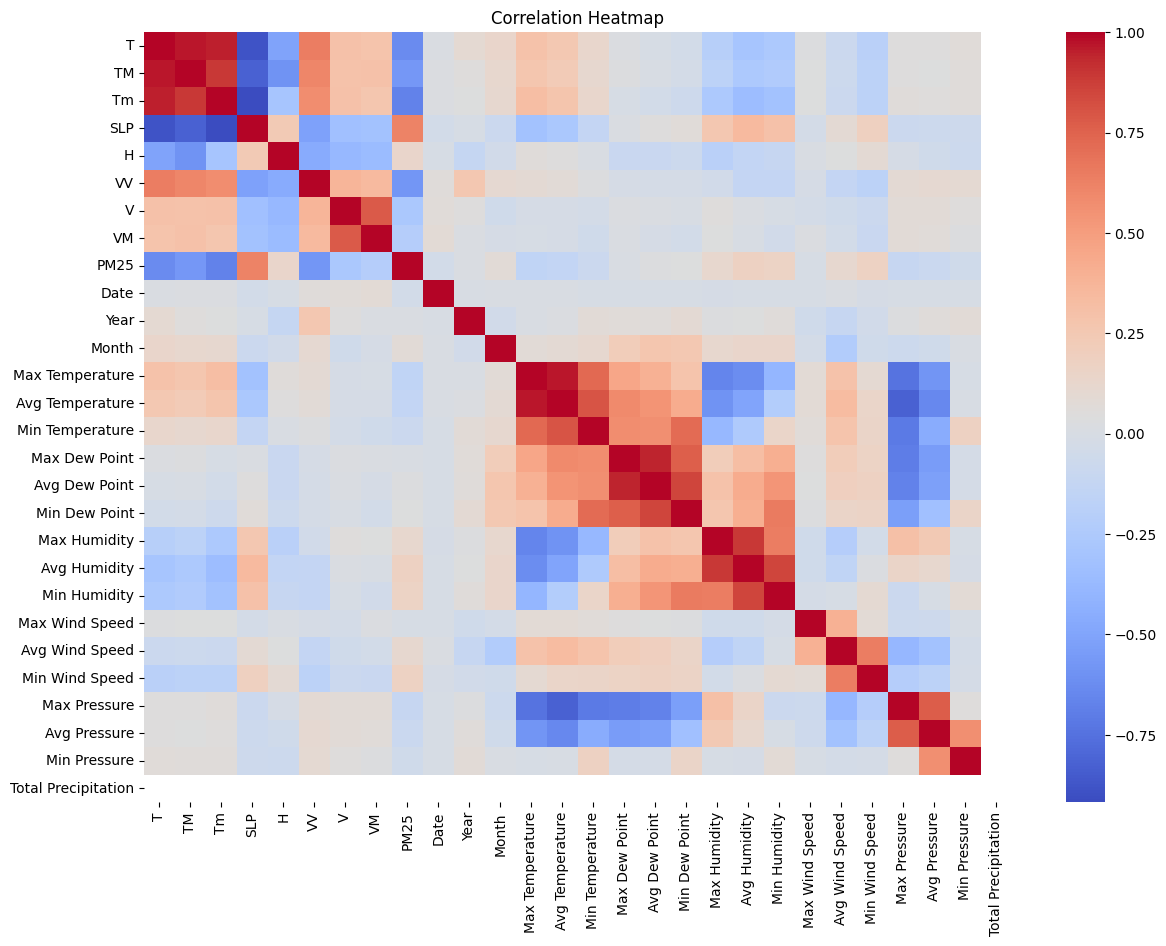

In [ ]:
# ====== STEP 4: EXPLORATORY DATA ANALYSIS ======

# Basic info
print(merged.info())
print(merged.describe())

# Missing values
print("Missing values:")
print(merged.isna().sum())

# Correlation heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,10))
sns.heatmap(merged.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


In [ ]:
# =========================
# 1. Prepare data for model
# =========================
model_df = merged.copy()

# Drop non-numeric / useless columns (keep only features you want)
model_df = model_df.drop(columns=['Date'], errors='ignore')  # keep if you don't have Date

target_col = 'PM25'

# Drop rows where target is missing
model_df = model_df.dropna(subset=[target_col])

X = model_df.drop(columns=[target_col])
y = model_df[target_col]

# =========================
# 2. Train-test split
# =========================
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# 3. Scale features
# =========================
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =========================
# 4. Baseline model: Linear Regression
# =========================
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

baseline = LinearRegression()
baseline.fit(X_train_scaled, y_train)

y_pred = baseline.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Baseline: Linear Regression")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)


Baseline: Linear Regression
MAE : 41.78625637957296
RMSE: 55.96645674870563
R²  : 0.49988619776891985


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Train the model
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=42
)
rf.fit(X_train, y_train)

# Predictions
pred_rf = rf.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, pred_rf)
rmse = np.sqrt(mean_squared_error(y_test, pred_rf))
r2 = r2_score(y_test, pred_rf)

print("Advanced Model: Random Forest")
print("MAE  :", mae)
print("RMSE :", rmse)
print("R²   :", r2)


Advanced Model: Random Forest
MAE  : 30.759016489091835
RMSE : 42.54948341663673
R²   : 0.7109308142971844


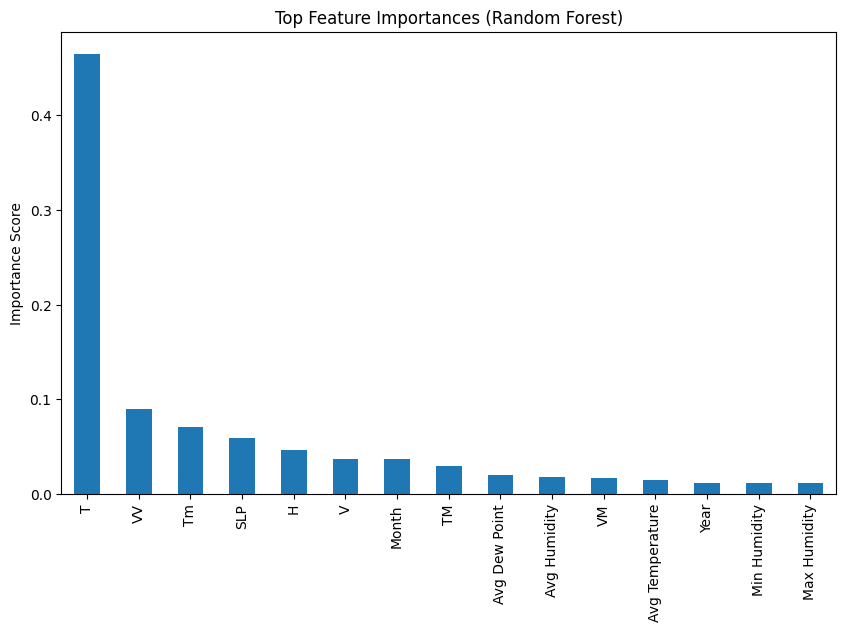

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

importances = rf.feature_importances_
feature_names = X.columns

fi = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10,6))
fi.head(15).plot(kind='bar')
plt.title("Top Feature Importances (Random Forest)")
plt.ylabel("Importance Score")
plt.show()


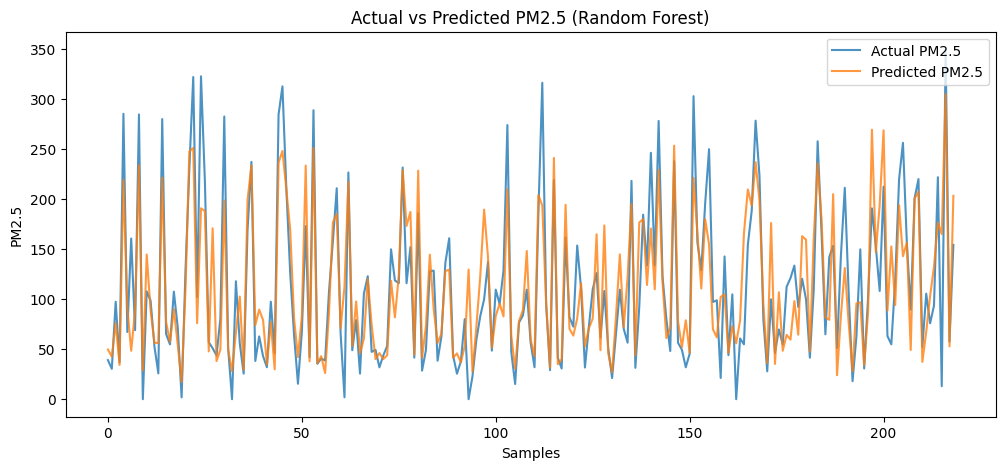

In [ ]:
import matplotlib.pyplot as plt

# Use Random Forest as your best model
best_model = rf

# Predict on test set
y_pred = best_model.predict(X_test)

# Plot
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label="Actual PM2.5", alpha=0.8)
plt.plot(y_pred, label="Predicted PM2.5", alpha=0.8)
plt.title("Actual vs Predicted PM2.5 (Random Forest)")
plt.xlabel("Samples")
plt.ylabel("PM2.5")
plt.legend()
plt.show()

**Model Evaluation Summary**

Baseline Model: Linear Regression

MAE: 41.78

RMSE: 55.96

R²: 0.49

Linear Regression performed poorly because the relationship between weather features and PM2.5 is non-linear, which simple linear models cannot capture.

**Advanced Model: Random Forest**

MAE: 30.76

RMSE: 42.54

R²: 0.71

Random Forest significantly improved accuracy because it captures non-linear interactions and feature interactions between weather variables.

**Interpretation of Feature Importance**

The Random Forest feature importance plot shows:

* Temperature (T) is the strongest predictor of PM2.5

* Wind Speed (V, VV) also has a strong effect

* Humidity (H) moderately affects PM2.5

* Pressure (SLP) has small but visible influence.

These patterns align with how pollution behaves in real life:

* Higher temperatures can increase chemical reactions that produce pollutants.

* Low wind speed traps polluted air.

* High humidity can increase particulate matter concentration.

**Interpretation of Actual vs Predicted PM2.5 Plot**

Final plot shows that:

*   The predicted curve follows the shape of the actual PM2.5 curve
*   Overall, the model generalizes well.
*   This visually confirms that Random Forest is a good choice.


**Final Conclusion**

The project demonstrates that AI can effectively forecast air quality using publicly available weather data. The Random Forest model achieved:

* 30% lower error compared to the baseline

* R² of ~0.71, meaning the model explains 71% of PM2.5 variations

Such forecasting systems can support:



*  Climate change mitigation
*  Pollution awareness
*  Public health decision-making










